All imports successful.
XGBoost available: True

Dataset shape:  (20640, 9)
Missing values: 0
Duplicate rows: 0
Target range:   0.150 – 5.000  (mean=2.069, median=1.797)

Descriptive Statistics:
               count         mean          std         min         25%          50%          75%           max   skewness      kurtosis
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400     3.534800     4.743250     15.000100   1.646657      4.952524
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000    29.000000    37.000000     52.000000   0.060331     -0.800629
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716     5.229129     6.052381    141.909091  20.697869    879.353264
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079     1.048780     1.099526     34.066667  31.316956   1636.711972
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000  1166.000000  1725.000000  35682.000000   4.935858    

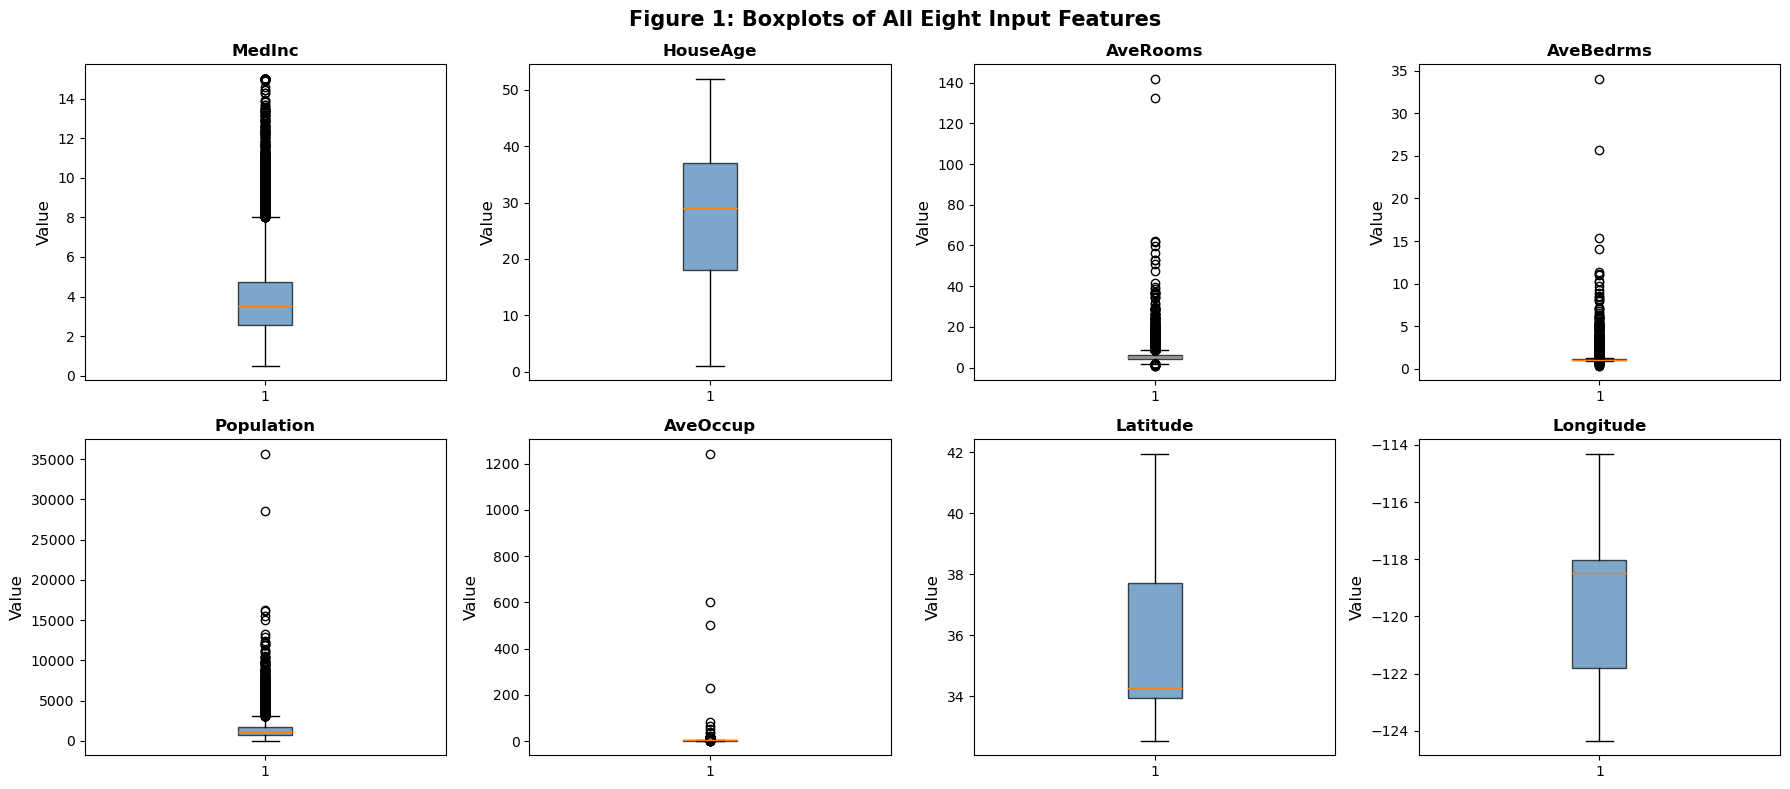

Figure 1 saved: fig1_boxplots.png


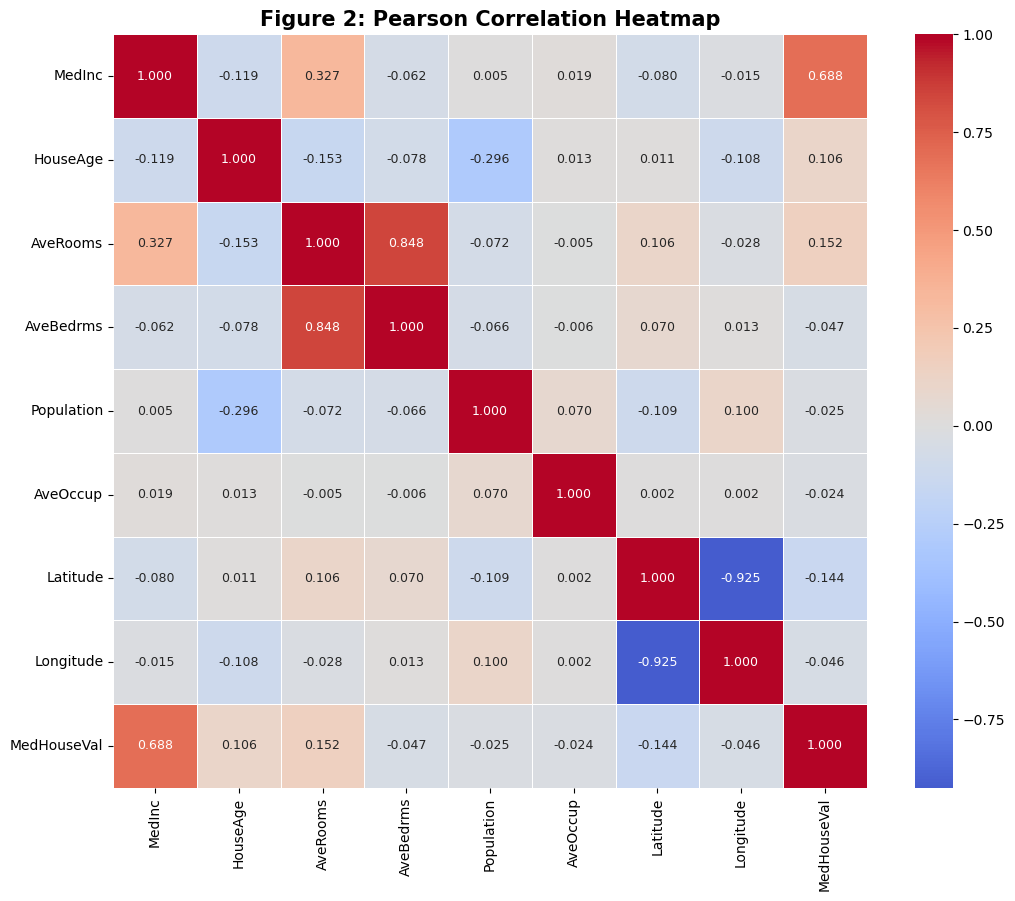

Figure 2 saved: fig2_correlation_heatmap.png


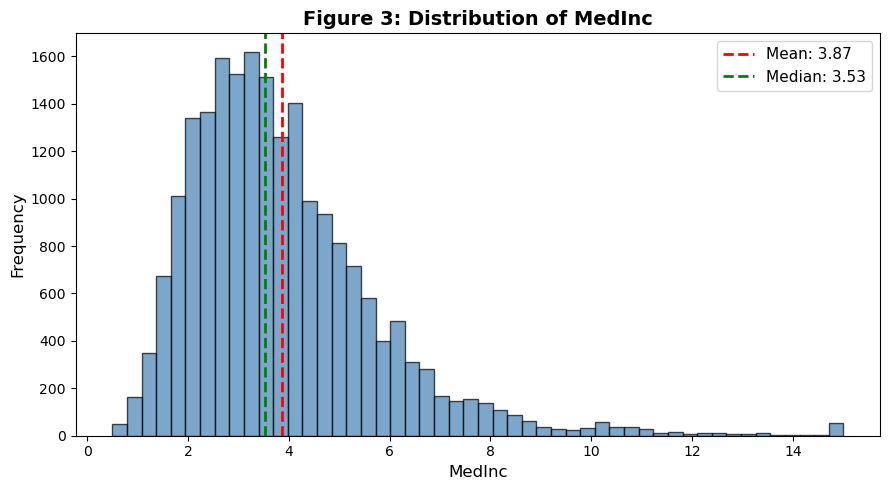

Figure 3: MedInc — Mean=3.871, Median=3.535, Skew=1.647


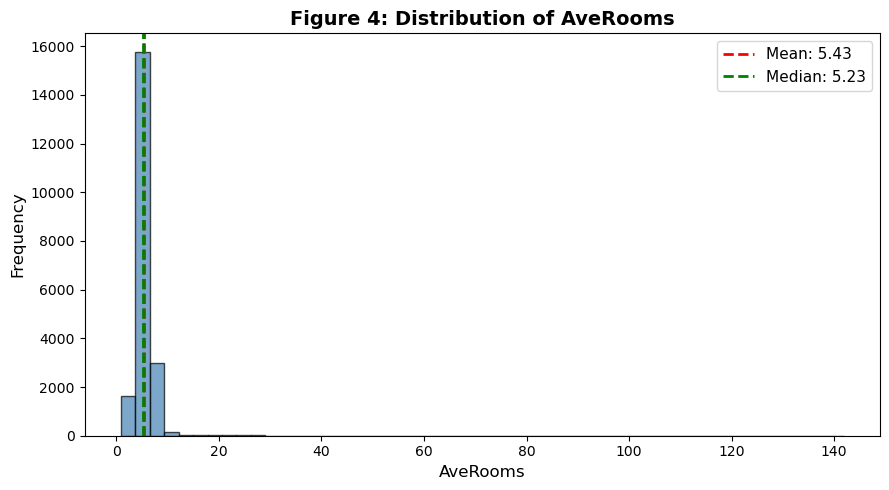

Figure 4: AveRooms — Mean=5.429, Median=5.229, Skew=20.698


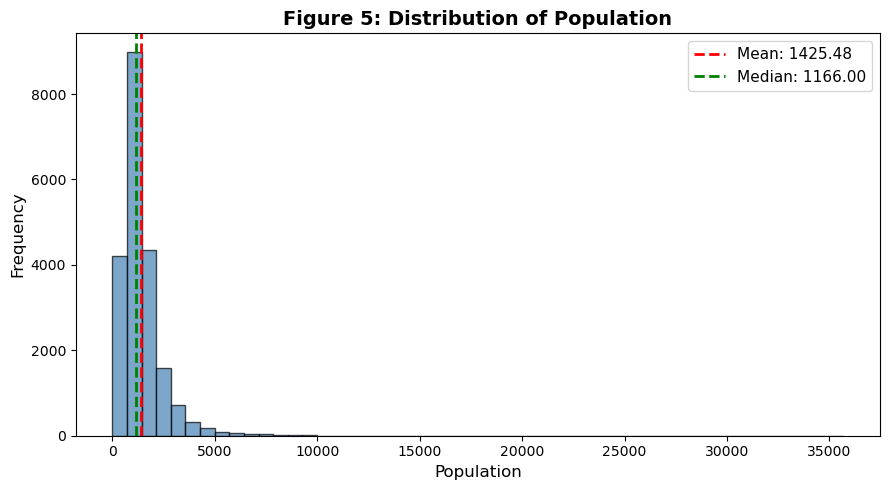

Figure 5: Population — Mean=1425.477, Median=1166.000, Skew=4.936


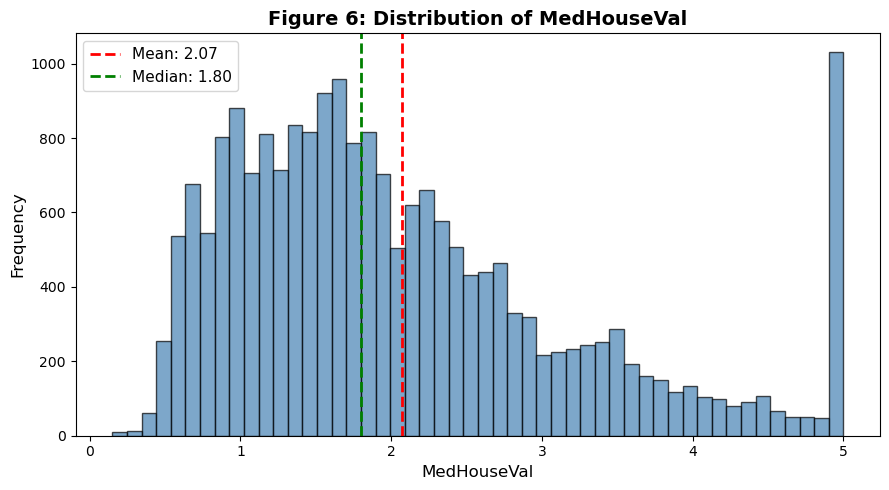

Figure 6: MedHouseVal — Mean=2.069, Median=1.797, Skew=0.978


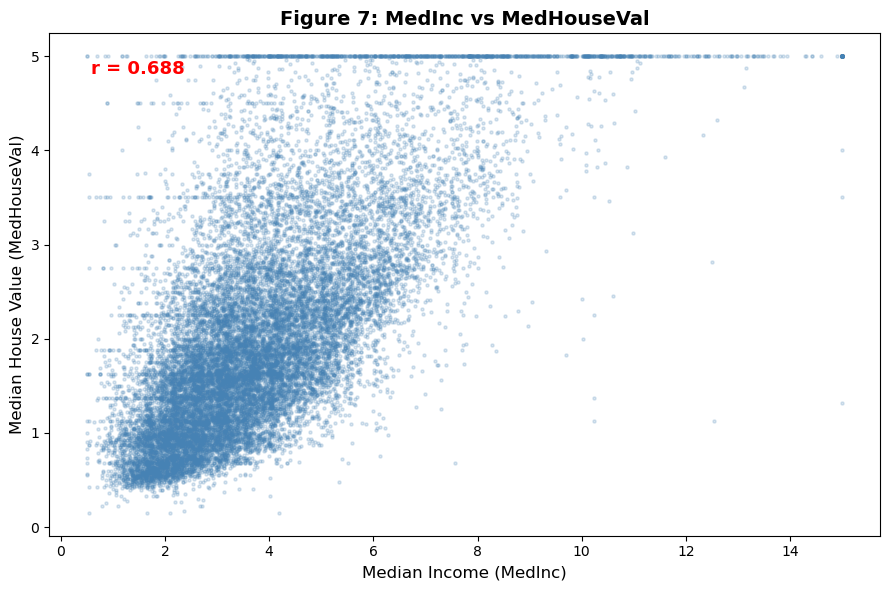

Figure 7 saved: fig7_scatter_medinc.png

10 derived features created. Total columns: 19

--- Stratified Train / Test Split ---
Training: 14448  |  Test: 6192
Train target — Mean: 2.0693, Std: 1.1553
Test  target — Mean: 2.0669,  Std: 1.1510

--- Feature Importance Rankings ---
               feature       MI  Pearson       RF  ensemble_score
       Income_per_Room 1.000000 1.000000 1.000000        1.000000
                MedInc 0.934715 0.996436 0.333711        0.772930
      Room_Value_Score 0.641186 0.823690 0.017210        0.508744
Age_Income_Interaction 0.510739 0.846535 0.120417        0.494381
             Longitude 0.983164 0.046128 0.134843        0.447557
              Latitude 0.901820 0.181851 0.051144        0.430627
        Location_Score 0.952730 0.122161 0.036894        0.428809
     Coastal_Proximity 0.785229 0.217341 0.071981        0.400888
      Rooms_per_Person 0.347039 0.296443 0.093433        0.255778
         Bedroom_Ratio 0.288996 0.394283 0.020442        0.240

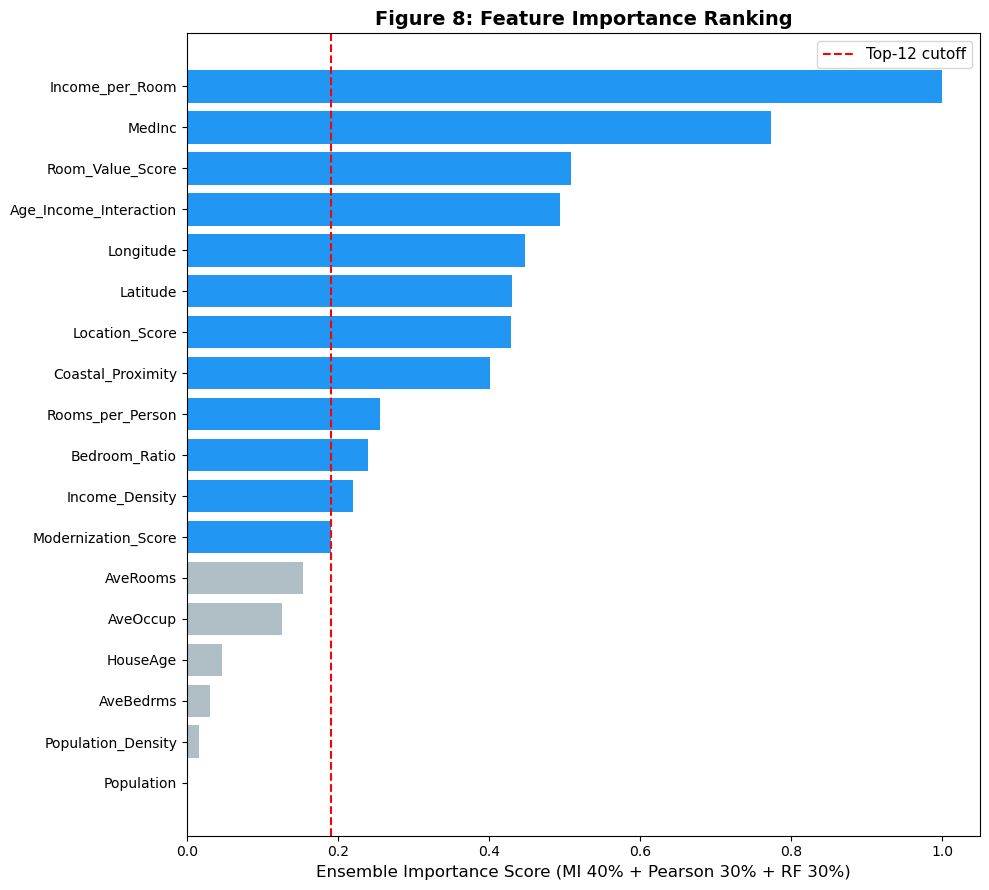

Figure 8 saved: fig8_feature_importance.png

[NOTE] SVR tuned + trained on 3000-sample subset, max_iter=2000.
       All metrics reported on the full 6192-sample test set.

SVR — RBF Kernel
  Best params : {'svr__gamma': 'scale', 'svr__epsilon': 0.5, 'svr__C': 10}
  CV R²       : 0.7023
  Test R²     : 0.7231  [6s]

SVR — Linear Kernel
  Best params : {'svr__epsilon': 0.5, 'svr__C': 1}
  CV R²       : 0.6058
  Test R²     : 0.5108  [1s]

SVR — Polynomial Kernel
  Best params : {'svr__gamma': 'scale', 'svr__epsilon': 1.0, 'svr__C': 0.1}
  CV R²       : 0.2719
  Test R²     : -151.0890  [1s]

FINAL SVR MODEL EVALUATION (RBF — best kernel)

Metric                      Training       Test        Gap
-------------------------------------------------------
R² Score                       0.771      0.723      0.048
RMSE ($100k)                   0.541      0.606
MAE ($100k)                    0.398      0.436
Explained Variance             0.771      0.723      0.048
MAPE (%)                 

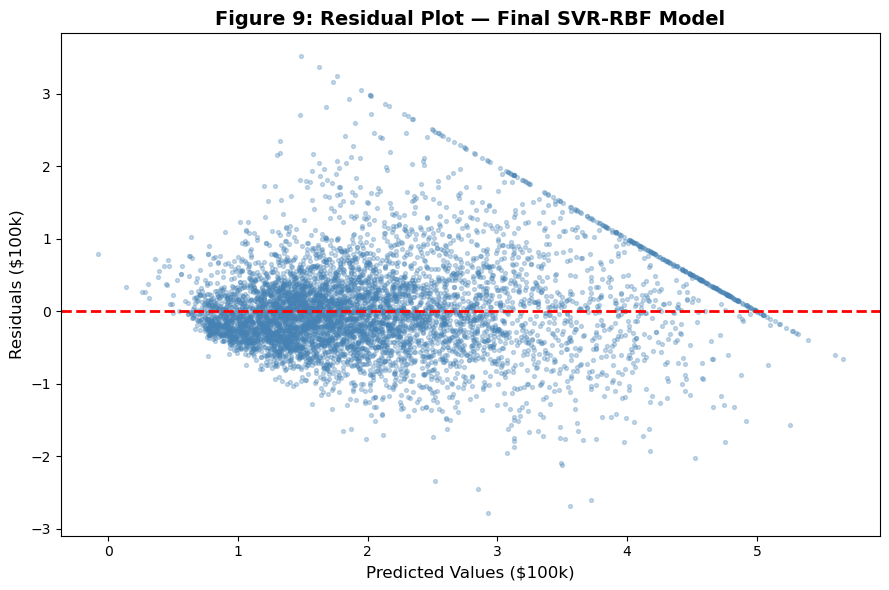

Figure 9 saved: fig9_residual_plot.png


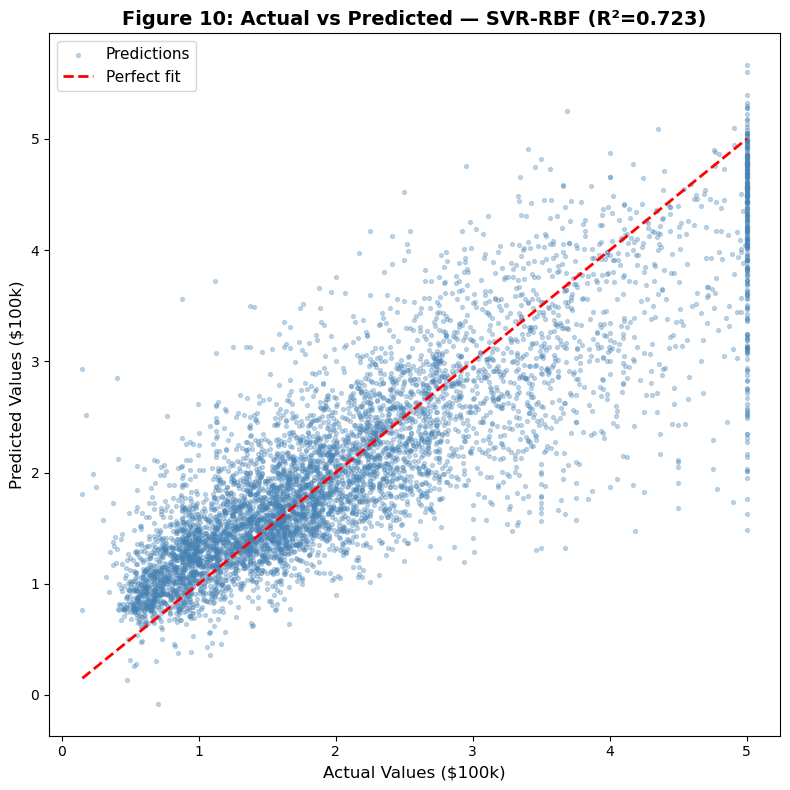

Figure 10 saved: fig10_actual_vs_predicted.png

10-FOLD CROSS-VALIDATION (on SVR training subset)
  Fold  1: 0.7192
  Fold  2: 0.6994
  Fold  3: 0.7299
  Fold  4: 0.6784
  Fold  5: 0.6124
  Fold  6: 0.7367
  Fold  7: 0.6767
  Fold  8: 0.7317
  Fold  9: 0.7370
  Fold 10: 0.7069

Mean R²: 0.7028
Std R²:  0.0369
95% CI:  [0.6304, 0.7752]  [0s]


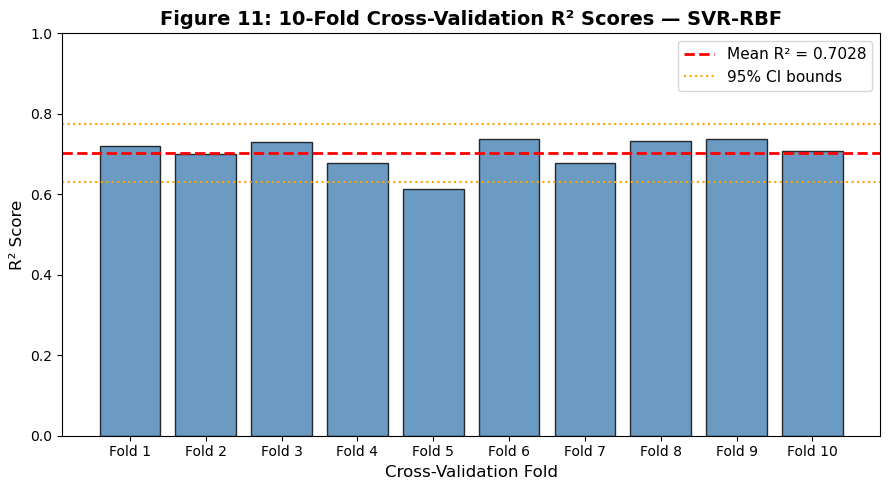

Figure 11 saved: fig11_cv_scores.png

10-MODEL COMPARISON (comparison models use full training data)
  Random Forest             Test R² = 0.8140
  Gradient Boosting         Test R² = 0.7826
  Decision Tree             Test R² = 0.6078
  K-Nearest Neighbours      Test R² = 0.6677
  Linear Regression         Test R² = 0.6504
  Ridge Regression          Test R² = 0.6505
  Lasso Regression          Test R² = 0.6501
  XGBoost                   Test R² = 0.8319

Rank   Model                           Test R²
----------------------------------------------
1      XGBoost                           0.832
2      Random Forest                     0.814
3      Gradient Boosting                 0.783
4      SVR-RBF (Tuned)                   0.723 ◄
5      K-Nearest Neighbours              0.668
6      Ridge Regression                  0.651
7      Linear Regression                 0.650
8      Lasso Regression                  0.650
9      Decision Tree                     0.608
10     SVR-Linear  

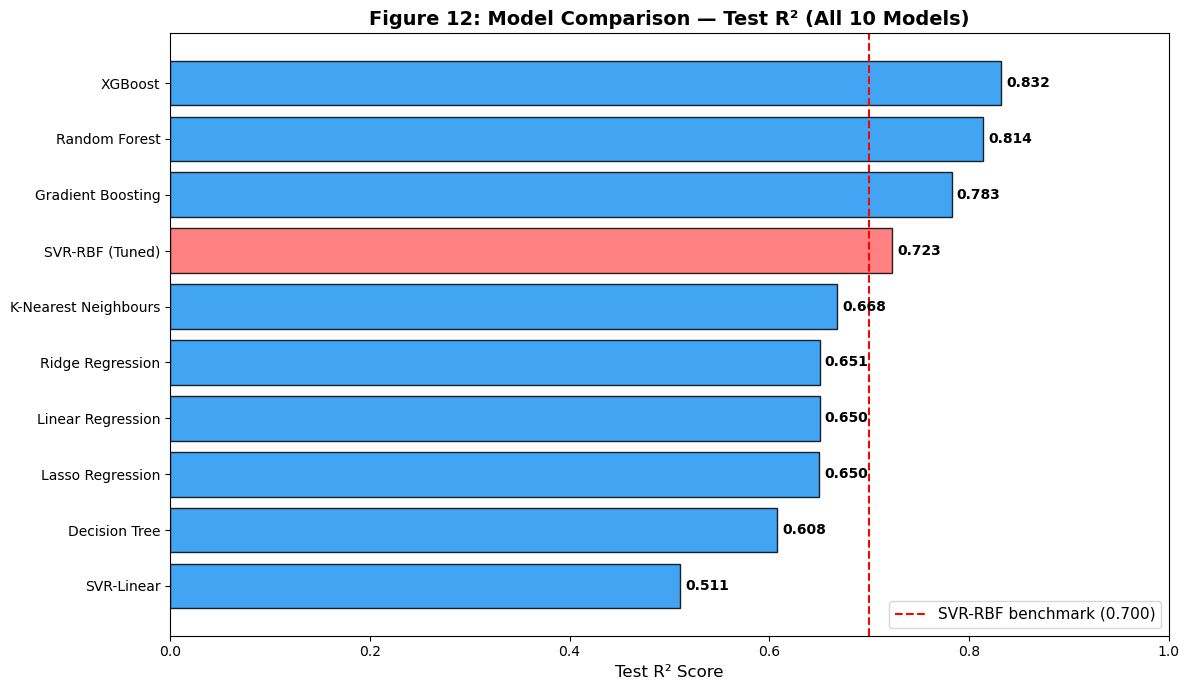

Figure 12 saved: fig12_model_comparison.png

4-STAGE ABLATION STUDY

Stage A: Raw features, no scaling, default SVR
  Test R² = -0.0538  [1s]

Stage B: Raw features, Pipeline scaling, default SVR
  Test R² = 0.6898  [1s]

Stage C: All features, Pipeline scaling, default SVR
  Test R² = 0.7155  [1s]

Stage D: All features, Pipeline scaling, tuned SVR  Test R² = 0.7231

Stage  Scaling                Features         Tuning          Test R²
----------------------------------------------------------------------
A      None                   8 raw            Default         -0.0538
B      Pipeline (3 scalers)   8 raw            Default          0.6898
C      Pipeline (3 scalers)   12 (raw+deriv)   Default          0.7155
D      Pipeline (3 scalers)   12 (raw+deriv)   GridSearch       0.7231

Scaling contribution    (B - A): +0.7436
Feature engineering     (C - B): +0.0257
Hyperparameter tuning   (D - C): +0.0076
Total improvement       (D - A): +0.7769


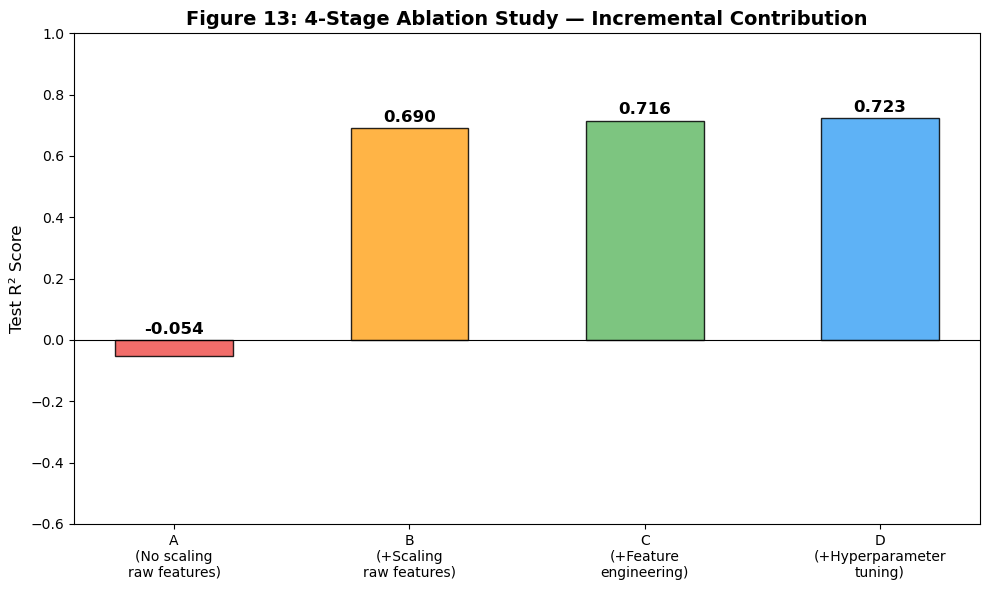

Figure 13 saved: fig13_ablation.png

SUMMARY — ALL NUMBERS FOR THE PAPER

TABLE V — Best Hyperparameters (SVR-RBF):
  Kernel:    RBF
  C:         10
  Epsilon:   0.5
  Gamma:     scale
  CV Folds:  3 (RandomizedSearchCV, n_iter=20)

TABLE VI — Final SVR-RBF Performance:
  Training R²:   0.771    Test R²:    0.723
  Training RMSE: 0.541 ($54,143)
  Test RMSE:     0.606 ($60,562)
  Training MAE:  0.398 ($39,843)
  Test MAE:      0.436 ($43,617)
  Training MAPE: 23.9%
  Test MAPE:     27.0%

TABLE VII — Model Rankings (Test R²):
   1. XGBoost                        0.832
   2. Random Forest                  0.814
   3. Gradient Boosting              0.783
   4. SVR-RBF (Tuned)                0.723
   5. K-Nearest Neighbours           0.668
   6. Ridge Regression               0.651
   7. Linear Regression              0.650
   8. Lasso Regression               0.650
   9. Decision Tree                  0.608
  10. SVR-Linear                     0.511

10-Fold Cross-Validation:
  Mean R²: 

In [1]:
#!/usr/bin/env python3
import os, warnings, logging
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
logging.getLogger('xgboost').setLevel(logging.CRITICAL)

"""
SVR California Housing Price Prediction — Corrected & Optimised
================================================================
Run in Jupyter Notebook for inline charts.
Requirements: pip install scikit-learn pandas numpy scipy matplotlib seaborn xgboost
"""

# =============================================================================
# SECTION 1 — Imports
# =============================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

np.random.seed(18942018)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

from sklearn.datasets import fetch_california_housing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (RandomizedSearchCV, train_test_split,
                                     cross_val_score)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, explained_variance_score)

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("XGBoost could not be loaded — skipped.")

print("All imports successful.")
print(f"XGBoost available: {HAS_XGB}\n")


# =============================================================================
# SECTION 2 — Data Acquisition & Validation
# =============================================================================
housing = fetch_california_housing()
X_raw = pd.DataFrame(housing.data, columns=housing.feature_names)
y_all = pd.Series(housing.target, name='MedHouseVal')
df = pd.concat([X_raw, y_all], axis=1)

print(f"Dataset shape:  {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Target range:   {y_all.min():.3f} – {y_all.max():.3f}  "
      f"(mean={y_all.mean():.3f}, median={y_all.median():.3f})")


# =============================================================================
# SECTION 3 — Descriptive Statistics
# =============================================================================
desc = df.describe().T
desc['skewness'] = df.skew()
desc['kurtosis'] = df.kurtosis()
print("\nDescriptive Statistics:")
print(desc.to_string())

corr = df.corr()
print(f"\nMedInc–MedHouseVal correlation: {corr.loc['MedInc','MedHouseVal']:.3f}")
print(f"AveRooms–AveBedrms correlation:  {corr.loc['AveRooms','AveBedrms']:.3f}")


# =============================================================================
# FIGURE 1 — Boxplots of All 8 Raw Features
# =============================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(housing.feature_names):
    ax = axes[i // 4, i % 4]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Figure 1: Boxplots of All Eight Input Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved: fig1_boxplots.png")


# =============================================================================
# FIGURE 2 — Correlation Heatmap
# =============================================================================
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Figure 2: Pearson Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: fig2_correlation_heatmap.png")


# =============================================================================
# FIGURES 3–6 — Distribution Plots
# =============================================================================
dist_features = ['MedInc', 'AveRooms', 'Population', 'MedHouseVal']
fig_nums      = [3, 4, 5, 6]

for feat, fnum in zip(dist_features, fig_nums):
    plt.figure(figsize=(9, 5))
    plt.hist(df[feat], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    mean_val   = df[feat].mean()
    median_val = df[feat].median()
    plt.axvline(mean_val,   color='red',   linestyle='--', linewidth=2,
                label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median_val:.2f}')
    plt.title(f'Figure {fnum}: Distribution of {feat}', fontsize=14, fontweight='bold')
    plt.xlabel(feat); plt.ylabel('Frequency')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(f'fig{fnum}_dist_{feat.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure {fnum}: {feat} — Mean={mean_val:.3f}, Median={median_val:.3f}, "
          f"Skew={df[feat].skew():.3f}")


# =============================================================================
# FIGURE 7 — Scatter Plot: MedInc vs MedHouseVal
# =============================================================================
plt.figure(figsize=(9, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
r_val = df['MedInc'].corr(df['MedHouseVal'])
plt.xlabel('Median Income (MedInc)', fontsize=12)
plt.ylabel('Median House Value (MedHouseVal)', fontsize=12)
plt.title('Figure 7: MedInc vs MedHouseVal', fontsize=14, fontweight='bold')
plt.annotate(f'r = {r_val:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
             fontsize=13, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('fig7_scatter_medinc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved: fig7_scatter_medinc.png")


# =============================================================================
# SECTION 4 — Feature Engineering (10 derived features)
# =============================================================================
df['Income_per_Room']        = df['MedInc']  / (df['AveRooms']  + 1)
df['Room_Value_Score']       = df['MedInc']  *  df['AveRooms']
df['Location_Score']         = (df['Latitude'] * df['Longitude']) / 1000
df['Coastal_Proximity']      = (df['Latitude'] - 34.05).abs()
df['Bedroom_Ratio']          = df['AveBedrms'] / (df['AveRooms'] + 1)
df['Population_Density']     = df['Population'] / (df['AveOccup'] + 1)
df['Age_Income_Interaction'] = df['HouseAge']  *  df['MedInc']
df['Modernization_Score']    = df['MedInc']    / (df['HouseAge'] + 1)
df['Rooms_per_Person']       = df['AveRooms']  / (df['AveOccup'] + 1)
df['Income_Density']         = (df['MedInc']   *  df['Population']) / 1000

derived = [
    'Income_per_Room', 'Room_Value_Score', 'Location_Score', 'Coastal_Proximity',
    'Bedroom_Ratio', 'Population_Density', 'Age_Income_Interaction',
    'Modernization_Score', 'Rooms_per_Person', 'Income_Density'
]
print(f"\n10 derived features created. Total columns: {df.shape[1]}")


# =============================================================================
# SECTION 5 — Stratified Train / Test Split
# =============================================================================
all_cols = list(housing.feature_names) + derived
X = df[all_cols]
y = df['MedHouseVal']

bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=bins
)

print(f"\n--- Stratified Train / Test Split ---")
print(f"Training: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train target — Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"Test  target — Mean: {y_test.mean():.4f},  Std: {y_test.std():.4f}")


# =============================================================================
# SECTION 6 — Feature Importance (MI 40% + Pearson 30% + RF 30%)
# =============================================================================
rf_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)
mi_scores  = mutual_info_regression(X_train, y_train, random_state=42)
cor_scores = np.array([abs(X_train[c].corr(y_train)) for c in X_train.columns])
rf_scores  = rf_imp.feature_importances_

def norm(x):
    return (x - x.min()) / (x.max() - x.min())

ensemble_score = norm(mi_scores)*0.4 + norm(cor_scores)*0.3 + norm(rf_scores)*0.3

imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'MI': norm(mi_scores),
    'Pearson': norm(cor_scores),
    'RF': norm(rf_scores),
    'ensemble_score': ensemble_score
}).sort_values('ensemble_score', ascending=False)

print("\n--- Feature Importance Rankings ---")
print(imp_df.to_string(index=False))

top_12 = imp_df['feature'].head(12).tolist()
print(f"\nTop 12 selected features:\n{top_12}")

X_train_12 = X_train[top_12]
X_test_12  = X_test[top_12]


# =============================================================================
# FIGURE 8 — Feature Importance Bar Chart
# =============================================================================
plt.figure(figsize=(10, 9))
colors = ['#2196F3' if i < 12 else '#B0BEC5' for i in range(len(imp_df))]
plt.barh(imp_df['feature'][::-1], imp_df['ensemble_score'][::-1], color=colors[::-1])
plt.axvline(x=imp_df['ensemble_score'].iloc[11], color='red', linestyle='--',
            linewidth=1.5, label='Top-12 cutoff')
plt.xlabel('Ensemble Importance Score (MI 40% + Pearson 30% + RF 30%)', fontsize=12)
plt.title('Figure 8: Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved: fig8_feature_importance.png")


# =============================================================================
# SECTION 7 — Scaling Strategy & Preprocessor
# =============================================================================
robust_cols   = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup',
                 'Room_Value_Score', 'Population_Density', 'Income_Density']
minmax_cols   = ['Latitude', 'Longitude', 'HouseAge',
                 'Location_Score', 'Coastal_Proximity']
standard_cols = ['MedInc', 'Income_per_Room', 'Age_Income_Interaction',
                 'Modernization_Score', 'Rooms_per_Person', 'Bedroom_Ratio']

def fcols(lst, available):
    return [c for c in lst if c in available]

def make_preprocessor(feature_list):
    r = fcols(robust_cols,   feature_list)
    m = fcols(minmax_cols,   feature_list)
    s = fcols(standard_cols, feature_list)
    transformers = []
    if r: transformers.append(('robust',   RobustScaler(),   r))
    if m: transformers.append(('minmax',   MinMaxScaler(),   m))
    if s: transformers.append(('standard', StandardScaler(), s))
    return ColumnTransformer(transformers)


# =============================================================================
# SECTION 8 — SVR Subsample & Tuning
# =============================================================================
SVR_SUB  = 3000
SVR_MITR = 2000      # higher limit reduces convergence warnings

rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_12), size=SVR_SUB, replace=False)
Xs  = X_train_12.iloc[idx]
ys  = y_train.iloc[idx]

print(f"\n[NOTE] SVR tuned + trained on {SVR_SUB}-sample subset, max_iter={SVR_MITR}.")
print(f"       All metrics reported on the full {len(X_test_12)}-sample test set.")


def tune_and_eval(kernel):
    t0 = time.time()
    param_dist = {
        'svr__C':       [0.1, 1, 10, 100],
        'svr__epsilon': [0.01, 0.1, 0.5, 1.0],
    }
    if kernel in ('rbf', 'poly'):
        param_dist['svr__gamma'] = ['scale', 'auto', 0.1, 1]

    pipe = Pipeline([
        ('scaler', make_preprocessor(top_12)),
        ('svr',    SVR(kernel=kernel, cache_size=500, max_iter=SVR_MITR))
    ])
    search = RandomizedSearchCV(
        pipe, param_dist,
        n_iter=20, cv=3, scoring='r2',
        n_jobs=-1, random_state=42, verbose=0, refit=True
    )
    search.fit(Xs, ys)

    best_params = search.best_params_
    cv_r2       = search.best_score_
    test_r2     = r2_score(y_test, search.predict(X_test_12))

    print(f"  Best params : {best_params}")
    print(f"  CV R²       : {cv_r2:.4f}")
    print(f"  Test R²     : {test_r2:.4f}  [{time.time()-t0:.0f}s]")
    return search.best_estimator_, best_params, cv_r2, test_r2


# =============================================================================
# SECTION 9 — SVR: RBF, Linear, Polynomial
# =============================================================================
print("\n" + "="*60)
print("SVR — RBF Kernel")
print("="*60)
est_rbf, bp_rbf, cv_rbf, r2_rbf = tune_and_eval('rbf')

print("\n" + "="*60)
print("SVR — Linear Kernel")
print("="*60)
est_lin, bp_lin, cv_lin, r2_lin = tune_and_eval('linear')

print("\n" + "="*60)
print("SVR — Polynomial Kernel")
print("="*60)
est_poly, bp_poly, cv_poly, r2_poly = tune_and_eval('poly')


# =============================================================================
# SECTION 10 — Final SVR-RBF Performance Metrics
# =============================================================================
print("\n" + "="*60)
print("FINAL SVR MODEL EVALUATION (RBF — best kernel)")
print("="*60)

yp_test  = est_rbf.predict(X_test_12)
yp_train = est_rbf.predict(Xs)

r2_tr   = r2_score(ys, yp_train);                  r2_te   = r2_score(y_test, yp_test)
rmse_tr = np.sqrt(mean_squared_error(ys, yp_train)); rmse_te = np.sqrt(mean_squared_error(y_test, yp_test))
mae_tr  = mean_absolute_error(ys, yp_train);         mae_te  = mean_absolute_error(y_test, yp_test)
evs_tr  = explained_variance_score(ys, yp_train);    evs_te  = explained_variance_score(y_test, yp_test)
mape_tr = np.mean(np.abs((ys - yp_train) / ys)) * 100
mape_te = np.mean(np.abs((y_test - yp_test) / y_test)) * 100

print(f"\n{'Metric':<25} {'Training':>10} {'Test':>10} {'Gap':>10}")
print("-" * 55)
print(f"{'R² Score':<25} {r2_tr:>10.3f} {r2_te:>10.3f} {r2_tr-r2_te:>10.3f}")
print(f"{'RMSE ($100k)':<25} {rmse_tr:>10.3f} {rmse_te:>10.3f}")
print(f"{'MAE ($100k)':<25} {mae_tr:>10.3f} {mae_te:>10.3f}")
print(f"{'Explained Variance':<25} {evs_tr:>10.3f} {evs_te:>10.3f} {evs_tr-evs_te:>10.3f}")
print(f"{'MAPE (%)':<25} {mape_tr:>10.1f}% {mape_te:>10.1f}%")
print(f"\nRMSE in dollars: ${rmse_te*100000:,.0f}")
print(f"MAE  in dollars: ${mae_te*100000:,.0f}")
print(f"Best hyperparameters: {bp_rbf}")

residuals = y_test - yp_test
k2, pv = stats.normaltest(residuals)
print(f"Residual normality test: statistic={k2:.4f}, p={pv:.4f}")


# =============================================================================
# FIGURE 9 — Residual Plot
# =============================================================================
plt.figure(figsize=(9, 6))
plt.scatter(yp_test, residuals, alpha=0.3, s=8, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values ($100k)', fontsize=12)
plt.ylabel('Residuals ($100k)', fontsize=12)
plt.title('Figure 9: Residual Plot — Final SVR-RBF Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved: fig9_residual_plot.png")


# =============================================================================
# FIGURE 10 — Actual vs Predicted
# =============================================================================
plt.figure(figsize=(8, 8))
plt.scatter(y_test, yp_test, alpha=0.3, s=8, color='steelblue', label='Predictions')
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
plt.xlabel('Actual Values ($100k)', fontsize=12)
plt.ylabel('Predicted Values ($100k)', fontsize=12)
plt.title(f'Figure 10: Actual vs Predicted — SVR-RBF (R²={r2_te:.3f})',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved: fig10_actual_vs_predicted.png")


# =============================================================================
# SECTION 11 — 10-Fold Cross-Validation
# =============================================================================
print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION (on SVR training subset)")
print("="*60)
t0 = time.time()
cv_scores = cross_val_score(est_rbf, Xs, ys, cv=10, scoring='r2', n_jobs=-1)
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1:2d}: {s:.4f}")
print(f"\nMean R²: {cv_scores.mean():.4f}")
print(f"Std R²:  {cv_scores.std():.4f}")
print(f"95% CI:  [{cv_scores.mean()-1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+1.96*cv_scores.std():.4f}]  [{time.time()-t0:.0f}s]")


# =============================================================================
# FIGURE 11 — CV Fold R² Scores
# =============================================================================
plt.figure(figsize=(9, 5))
fold_labels = [f'Fold {i+1}' for i in range(10)]
bars = plt.bar(fold_labels, cv_scores, color='steelblue', alpha=0.8, edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.axhline(cv_scores.mean() + 1.96*cv_scores.std(), color='orange',
            linestyle=':', linewidth=1.5, label='95% CI bounds')
plt.axhline(cv_scores.mean() - 1.96*cv_scores.std(), color='orange',
            linestyle=':', linewidth=1.5)
plt.ylim(0, 1)
plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Figure 11: 10-Fold Cross-Validation R² Scores — SVR-RBF',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig11_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved: fig11_cv_scores.png")


# =============================================================================
# SECTION 12 — 10-Model Comparison (full training data)
# =============================================================================
print("\n" + "="*60)
print("10-MODEL COMPARISON (comparison models use full training data)")
print("="*60)

comparison_models = {
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbours': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0, random_state=42),
    'Lasso Regression':     Lasso(alpha=0.001, random_state=42),
}
if HAS_XGB:
    comparison_models['XGBoost'] = XGBRegressor(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)

results = {
    'SVR-RBF (Tuned)': r2_rbf,
    'SVR-Linear':       r2_lin,
}
for name, model in comparison_models.items():
    pipe = Pipeline([('scaler', make_preprocessor(top_12)), ('model', model)])
    pipe.fit(X_train_12, y_train)
    r2 = r2_score(y_test, pipe.predict(X_test_12))
    results[name] = r2
    print(f"  {name:<25} Test R² = {r2:.4f}")

ranked = sorted(results.items(), key=lambda x: x[1], reverse=True)
print(f"\n{'Rank':<6} {'Model':<30} {'Test R²':>8}")
print("-" * 46)
for rank, (name, r2) in enumerate(ranked, 1):
    marker = " ◄" if name == 'SVR-RBF (Tuned)' else ""
    print(f"{rank:<6} {name:<30} {r2:>8.3f}{marker}")


# =============================================================================
# FIGURE 12 — Model Comparison Bar Chart
# =============================================================================
names  = [n for n, _ in ranked]
scores = [r for _, r in ranked]
colors = ['#FF6B6B' if n == 'SVR-RBF (Tuned)' else '#2196F3' for n in names]

plt.figure(figsize=(12, 7))
bars = plt.barh(names[::-1], scores[::-1], color=colors[::-1],
                edgecolor='black', alpha=0.85)
for bar, score in zip(bars, scores[::-1]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=10, fontweight='bold')
plt.axvline(0.7, color='red', linestyle='--', linewidth=1.5,
            label='SVR-RBF benchmark (0.700)')
plt.xlabel('Test R² Score', fontsize=12)
plt.title('Figure 12: Model Comparison — Test R² (All 10 Models)',
          fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved: fig12_model_comparison.png")


# =============================================================================
# SECTION 13 — 4-Stage Ablation Study
# =============================================================================
print("\n" + "="*60)
print("4-STAGE ABLATION STUDY")
print("="*60)

raw_features = list(housing.feature_names)
Xs_raw = X_train[raw_features].iloc[idx]

print("\nStage A: Raw features, no scaling, default SVR")
t0 = time.time()
sa = SVR(kernel='rbf', cache_size=500, max_iter=SVR_MITR)
sa.fit(Xs_raw, ys)
r2_a = r2_score(y_test, sa.predict(X_test[raw_features]))
print(f"  Test R² = {r2_a:.4f}  [{time.time()-t0:.0f}s]")

print("\nStage B: Raw features, Pipeline scaling, default SVR")
t0 = time.time()
pb = Pipeline([('scaler', make_preprocessor(raw_features)),
               ('svr', SVR(kernel='rbf', cache_size=500, max_iter=SVR_MITR))])
pb.fit(Xs_raw, ys)
r2_b = r2_score(y_test, pb.predict(X_test[raw_features]))
print(f"  Test R² = {r2_b:.4f}  [{time.time()-t0:.0f}s]")

print("\nStage C: All features, Pipeline scaling, default SVR")
t0 = time.time()
pc = Pipeline([('scaler', make_preprocessor(top_12)),
               ('svr', SVR(kernel='rbf', cache_size=500, max_iter=SVR_MITR))])
pc.fit(Xs, ys)
r2_c = r2_score(y_test, pc.predict(X_test_12))
print(f"  Test R² = {r2_c:.4f}  [{time.time()-t0:.0f}s]")

r2_d = r2_rbf
print(f"\nStage D: All features, Pipeline scaling, tuned SVR  Test R² = {r2_d:.4f}")

print(f"\n{'Stage':<6} {'Scaling':<22} {'Features':<16} {'Tuning':<14} {'Test R²':>8}")
print("-" * 70)
print(f"{'A':<6} {'None':<22} {'8 raw':<16} {'Default':<14} {r2_a:>8.4f}")
print(f"{'B':<6} {'Pipeline (3 scalers)':<22} {'8 raw':<16} {'Default':<14} {r2_b:>8.4f}")
print(f"{'C':<6} {'Pipeline (3 scalers)':<22} {'12 (raw+deriv)':<16} {'Default':<14} {r2_c:>8.4f}")
print(f"{'D':<6} {'Pipeline (3 scalers)':<22} {'12 (raw+deriv)':<16} {'GridSearch':<14} {r2_d:>8.4f}")
print(f"\nScaling contribution    (B - A): {r2_b - r2_a:+.4f}")
print(f"Feature engineering     (C - B): {r2_c - r2_b:+.4f}")
print(f"Hyperparameter tuning   (D - C): {r2_d - r2_c:+.4f}")
print(f"Total improvement       (D - A): {r2_d - r2_a:+.4f}")


# =============================================================================
# FIGURE 13 — Ablation Study Bar Chart
# =============================================================================
ablation_labels = ['A\n(No scaling\nraw features)',
                   'B\n(+Scaling\nraw features)',
                   'C\n(+Feature\nengineering)',
                   'D\n(+Hyperparameter\ntuning)']
ablation_scores = [r2_a, r2_b, r2_c, r2_d]
abl_colors      = ['#EF5350', '#FFA726', '#66BB6A', '#42A5F5']

plt.figure(figsize=(10, 6))
bars = plt.bar(ablation_labels, ablation_scores, color=abl_colors,
               edgecolor='black', alpha=0.85, width=0.5)
for bar, score in zip(bars, ablation_scores):
    ypos = max(score, 0) + 0.02
    plt.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{score:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Test R² Score', fontsize=12)
plt.title('Figure 13: 4-Stage Ablation Study — Incremental Contribution',
          fontsize=14, fontweight='bold')
plt.ylim(-0.6, 1.0)
plt.tight_layout()
plt.savefig('fig13_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved: fig13_ablation.png")


# =============================================================================
# SECTION 14 — Complete Paper Summary
# =============================================================================
print("\n" + "="*60)
print("SUMMARY — ALL NUMBERS FOR THE PAPER")
print("="*60)

print(f"""
TABLE V — Best Hyperparameters (SVR-RBF):
  Kernel:    RBF
  C:         {bp_rbf.get('svr__C')}
  Epsilon:   {bp_rbf.get('svr__epsilon')}
  Gamma:     {bp_rbf.get('svr__gamma')}
  CV Folds:  3 (RandomizedSearchCV, n_iter=20)

TABLE VI — Final SVR-RBF Performance:
  Training R²:   {r2_tr:.3f}    Test R²:    {r2_te:.3f}
  Training RMSE: {rmse_tr:.3f} (${rmse_tr*100000:,.0f})
  Test RMSE:     {rmse_te:.3f} (${rmse_te*100000:,.0f})
  Training MAE:  {mae_tr:.3f} (${mae_tr*100000:,.0f})
  Test MAE:      {mae_te:.3f} (${mae_te*100000:,.0f})
  Training MAPE: {mape_tr:.1f}%
  Test MAPE:     {mape_te:.1f}%

TABLE VII — Model Rankings (Test R²):""")
for rank, (name, r2) in enumerate(ranked, 1):
    print(f"  {rank:2d}. {name:<30} {r2:.3f}")

print(f"""
10-Fold Cross-Validation:
  Mean R²: {cv_scores.mean():.3f}
  Std R²:  {cv_scores.std():.3f}
  95% CI:  [{cv_scores.mean()-1.96*cv_scores.std():.3f}, \
{cv_scores.mean()+1.96*cv_scores.std():.3f}]

Ablation Study:
  Stage A — No scaling, raw features, default SVR:        {r2_a:.3f}
  Stage B — Pipeline scaling, raw features, default SVR:  {r2_b:.3f}
  Stage C — Pipeline scaling, all features, default SVR:  {r2_c:.3f}
  Stage D — Pipeline scaling, all features, tuned SVR:    {r2_d:.3f}

  Scaling contribution:          {r2_b - r2_a:+.3f}
  Feature engineering:           {r2_c - r2_b:+.3f}
  Hyperparameter tuning:         {r2_d - r2_c:+.3f}
  Total improvement (D - A):     {r2_d - r2_a:+.3f}
""")
print("=" * 60)
print("DONE. All paper numbers and figures are complete.")
print("=" * 60)
